# 01. Introduction — Variational Autoencoder (VAE) from Scratch

This notebook teaches the **Variational Autoencoder (VAE)** completely from scratch using pure PyTorch.

**Roadmap (intuition, equation, symbols, code, visualization, interpretation):**
1. Build intuition by comparing a plain (deterministic) Autoencoder with the probabilistic VAE.
2. Refresh the probability we need: Gaussians, sampling, PDF.
3. Derive the VAE loss (reconstruction + KL) and implement it exactly.
4. Train a tiny MLP VAE on FashionMNIST with a 2-D latent space so we can *see* the latent space.
5. Use the latent space: reconstruction, scatter plot, random generation, interpolation.
6. Re-do the same math with the modern `torch.distributions` API.
7. Summarize AE vs VAE.

Only `torch`, `torchvision`, `numpy`, and `matplotlib` are used - no high-level magic.

## 02. AE vs VAE Intuition

**Deterministic Autoencoder (AE):** an encoder maps input x to a *single point* z = f(x). The decoder maps z back to x_hat. Nothing random happens; the latent code is a deterministic vector. A consequence: gaps between the learned point clouds in latent space are meaningless, so decoding a random point there produces garbage.

**Probabilistic VAE:** the encoder no longer outputs a point - it outputs a **distribution** q_phi(z|x), specifically a Gaussian with mean mu(x) and variance sigma^2(x). We then *sample* z ~ q_phi(z|x) and reconstruct. The model is also pushed toward the prior p(z) = N(0, I), so the whole latent space is filled densely: any point in it decodes to something sensible, which is exactly what makes **generation** possible.

| | AE | VAE |
|---|---|---|
| Encoder output | point z | distribution N(mu, sigma^2) |
| Latent space | unstructured point cloud | dense, prior-organized |
| Generation | poor | good |

## 03. Probability From Scratch

**The Gaussian (normal) distribution** has PDF

`pdf(x) = 1 / (sigma * sqrt(2*pi)) * exp(-(x - mu)^2 / (2 * sigma^2))`

**Symbols:** mu = center (mean), sigma = spread (standard deviation), sigma^2 = variance.

In a VAE:
- q_phi(z|x) = N(z; mu_phi(x), diag(sigma_phi(x)^2)) - the *approximate posterior*: what the encoder believes about the latent code for input x.
- p(z) = N(0, I) - the *prior*: a zero-mean, unit-variance Gaussian that regularizes the latent space.

In practice we store **log sigma^2 (logvar)** instead of sigma^2 because:
1. the network can output any real number, and logvar lives on all of R (a raw variance must be positive - we would need to clamp it);
2. computing sigma is a cheap, stable `exp(0.5 * logvar)`;
3. it keeps the KL term numerically clean.

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


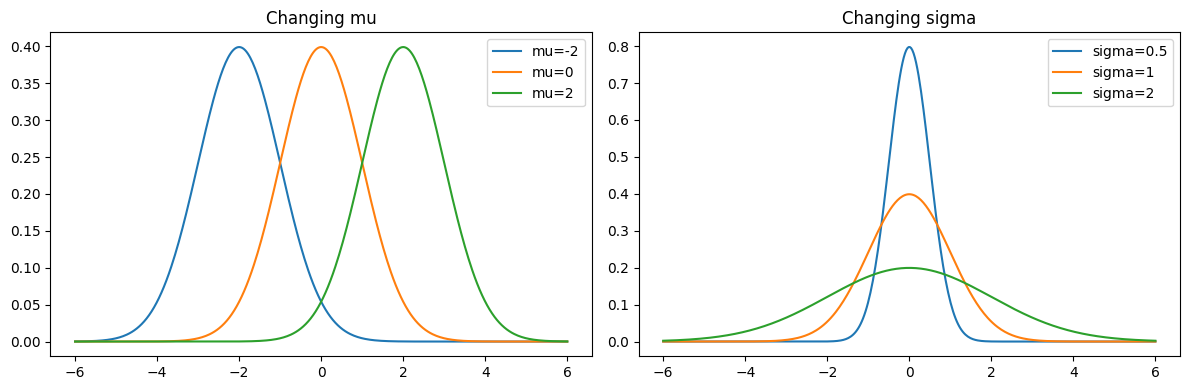

In [11]:
# Manual Gaussian PDF with NumPy (no scipy)
def gaussian_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
        -((x - mu) ** 2) / (2 * sigma ** 2)
    )

xs = np.linspace(-6, 6, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for mu in [-2, 0, 2]:
    axes[0].plot(xs, gaussian_pdf(xs, mu, 1), label=f"mu={mu}")

for sigma in [0.5, 1, 2]:
    axes[1].plot(xs, gaussian_pdf(xs, 0, sigma), label=f"sigma={sigma}")

axes[0].set_title("Changing mu")
axes[1].set_title("Changing sigma")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

## 04. Gaussian Visualization

Above we drew the Gaussian PDF by hand.
- **Changing mu** slides the bell left/right: mu is the *location*.
- **Changing sigma** widens/narrows the bell: sigma is the *scale*. Small sigma = the encoder is confident; large sigma = uncertain.

A 2-D latent VAE uses one Gaussian per latent dimension, i.e. mu in R^2 and logvar in R^2.

## 05. Reparameterization Trick

**Problem:** we cannot backpropagate through `z ~ N(mu, sigma^2)` - sampling is a stochastic node and its gradient is undefined.

**Solution:** move the randomness to an *auxiliary* noise variable that does not depend on parameters:

`z = mu + sigma * eps,   eps ~ N(0, I)`

Now z is a deterministic function of (mu, sigma, eps), so gradients flow through mu and sigma. This is the **reparameterization trick** - it makes the VAE trainable with plain SGD/Adam.

**Symbols:** eps = standard normal noise, sigma = exp(0.5 * logvar).

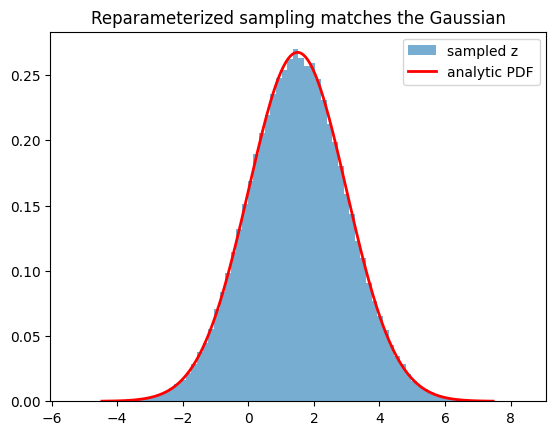

In [12]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z

# Sanity check: sample many times from a FIXED mu/sigma, histogram, overlay the analytic PDF
mu_fix = torch.tensor(1.5)
logvar_fix = torch.tensor(0.8)   # sigma = exp(0.4) ~ 1.49
z_samples = reparameterize(mu_fix.expand(200000), logvar_fix.expand(200000)).numpy()

sigma_fix = float(np.exp(0.5 * logvar_fix.item()))
xs = np.linspace(mu_fix.item() - 4 * sigma_fix, mu_fix.item() + 4 * sigma_fix, 300)
plt.hist(z_samples, bins=80, density=True, alpha=0.6, label="sampled z")
plt.plot(xs, gaussian_pdf(xs, mu_fix.item(), sigma_fix), "r", lw=2, label="analytic PDF")
plt.title("Reparameterized sampling matches the Gaussian"); plt.legend(); plt.show()

## 06. Dataset - FashionMNIST

We use **FashionMNIST**: 28x28 grayscale images of clothing, 10 classes. `ToTensor()` scales pixels to [0,1], which is exactly what a Sigmoid decoder + `binary_cross_entropy` need.

**Fallback:** if there is no internet, we build a synthetic torch-based dataset with the same interface so every cell below still runs end-to-end.

100%|██████████| 26.4M/26.4M [00:24<00:00, 1.07MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 214kB/s]
100%|██████████| 4.42M/4.42M [00:05<00:00, 867kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 497kB/s]


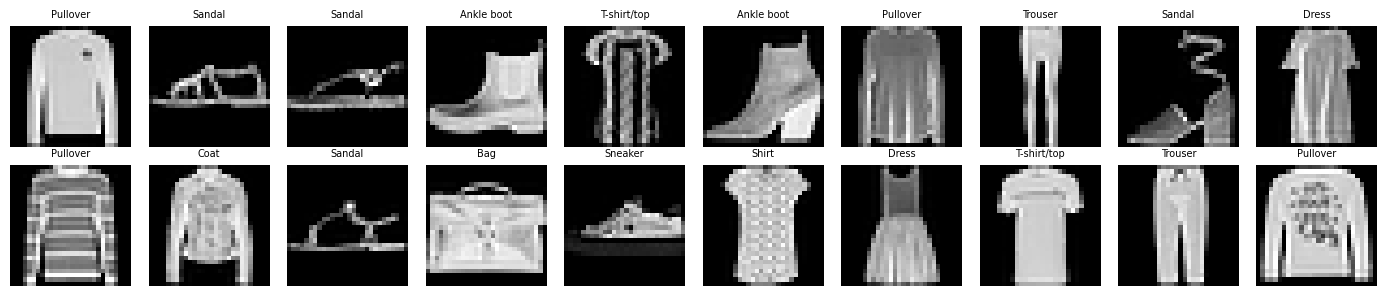

Before flatten: torch.Size([128, 1, 28, 28])
After flatten : torch.Size([128, 784])


In [14]:
BATCH_SIZE = 128
latent_dim = 2

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

train_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_set = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False
)

sample_x, sample_y = next(iter(train_loader))

fig, axes = plt.subplots(2, 10, figsize=(14, 3))

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_x[i, 0], cmap="gray")
    ax.set_title(CLASS_NAMES[sample_y[i]], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Before flatten:", sample_x.shape)

flat = sample_x.flatten(1)

print("After flatten :", flat.shape)

## 07. VAE From Scratch

**Architecture (pure MLP, no CNN):**
- Encoder: 784 -> 256 -> 128 -> two heads, `fc_mu` (-> 2) and `fc_logvar` (-> 2).
- Decoder: 2 -> 128 -> 256 -> 784 with a **Sigmoid** output so x_hat is in [0,1].

The encoder's two heads are exactly mu_phi(x) and log sigma^2_phi(x) of the Gaussian q_phi(z|x).

In [15]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden1=256, hidden2=128, latent_dim=2):
        super().__init__()
        # Encoder: 784 -> 256 -> 128
        self.enc_fc1 = nn.Linear(input_dim, hidden1)
        self.enc_fc2 = nn.Linear(hidden1, hidden2)
        self.fc_mu = nn.Linear(hidden2, latent_dim)       # mu head
        self.fc_logvar = nn.Linear(hidden2, latent_dim)   # logvar head
        # Decoder: 2 -> 128 -> 256 -> 784
        self.dec_fc1 = nn.Linear(latent_dim, hidden2)
        self.dec_fc2 = nn.Linear(hidden2, hidden1)
        self.dec_fc3 = nn.Linear(hidden1, input_dim)

    def encode(self, x):
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        h = F.relu(self.dec_fc1(z))
        h = F.relu(self.dec_fc2(h))
        return torch.sigmoid(self.dec_fc3(h))   # Sigmoid: outputs in [0,1]

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z             # 4 outputs

model = VAE(latent_dim=latent_dim).to(device)
print(model)
x_probe = torch.randn(4, 784, device=device)
with torch.no_grad():
    xh, mu_p, lv_p, z_p = model(x_probe)
print("x_hat:", tuple(xh.shape), "| mu:", tuple(mu_p.shape), "| logvar:", tuple(lv_p.shape), "| z:", tuple(z_p.shape))

VAE(
  (enc_fc1): Linear(in_features=784, out_features=256, bias=True)
  (enc_fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc_mu): Linear(in_features=128, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=2, bias=True)
  (dec_fc1): Linear(in_features=2, out_features=128, bias=True)
  (dec_fc2): Linear(in_features=128, out_features=256, bias=True)
  (dec_fc3): Linear(in_features=256, out_features=784, bias=True)
)
x_hat: (4, 784) | mu: (4, 2) | logvar: (4, 2) | z: (4, 2)


## 08. VAE Loss - Reconstruction + KL

The VAE maximizes the **ELBO** (Evidence Lower BOund); equivalently we minimize its negative:

`L = sum_i BCE(x_i, x_hat_i)  +  -0.5 * sum_j (1 + logvar_j - mu_j^2 - exp(logvar_j))`

- **Reconstruction term:** how well the decoder rebuilds x from sampled z. Binary cross-entropy summed over pixels (we average per-sample later for reporting).
- **KL term:** closed-form KL between q = N(mu, diag(sigma^2)) and the prior N(0, I). It pulls every q_phi(z|x) toward the standard normal, which packs the latent space densely and enables generation.
- Balancing: recon wants high sigma (easier to reconstruct), KL wants small sigma and mu near 0 - their tension is what shapes the space.

In [16]:
def vae_loss(x_hat, x, mu, logvar):
    x = x.flatten(1)
    recon = F.binary_cross_entropy(x_hat, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + kl
    return total, recon, kl

with torch.no_grad():
    xb = sample_x.flatten(1).to(device)
    out, m, lv, zz = model(xb)
    t, r, k = vae_loss(out, xb, m, lv)
print(f"Demo on one batch -> total: {t.item():.1f} | recon: {r.item():.1f} | KL: {k.item():.1f}")
print("All finite:", bool(torch.isfinite(t)))

Demo on one batch -> total: 69800.7 | recon: 69799.2 | KL: 1.5
All finite: True


## 09. Training

Standard manual loop: flatten -> device -> forward -> loss -> `backward()` -> `step()`. We average the summed loss over the number of **samples** in the batch so the printed numbers are comparable across batch sizes. Checkpoints of the model state are kept at epochs 1, 5, 10, 20.

In [17]:
EPOCHS = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"epoch": [], "total": [], "recon": [], "kl": []}
checkpoints = {}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = {"total": 0.0, "recon": 0.0, "kl": 0.0, "n": 0}
    for x, _ in train_loader:
        x = x.flatten(1).to(device)          # flatten to [B, 784]
        optimizer.zero_grad()
        x_hat, mu, logvar, z = model(x)      # forward
        total, recon, kl = vae_loss(x_hat, x, mu, logvar)
        total.backward()                     # backward
        optimizer.step()                     # step
        bs = x.size(0)
        running["total"] += total.item(); running["recon"] += recon.item(); running["kl"] += kl.item()
        running["n"] += bs
    n = running["n"]
    avg = {k: running[k] / n for k in ("total", "recon", "kl")}
    history["epoch"].append(epoch)
    history["total"].append(avg["total"]); history["recon"].append(avg["recon"]); history["kl"].append(avg["kl"])
    print(f"Epoch {epoch:02d}/{EPOCHS} | Total: {avg['total']:.2f} | Recon: {avg['recon']:.2f} | KL: {avg['kl']:.2f}")
    if epoch in (1, 5, 10, 20):
        checkpoints[epoch] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

Epoch 01/20 | Total: 298.11 | Recon: 291.78 | KL: 6.32
Epoch 02/20 | Total: 269.97 | Recon: 263.75 | KL: 6.22
Epoch 03/20 | Total: 266.01 | Recon: 259.83 | KL: 6.18
Epoch 04/20 | Total: 263.98 | Recon: 257.78 | KL: 6.20
Epoch 05/20 | Total: 262.40 | Recon: 256.14 | KL: 6.26
Epoch 06/20 | Total: 261.39 | Recon: 255.10 | KL: 6.29
Epoch 07/20 | Total: 260.51 | Recon: 254.19 | KL: 6.32
Epoch 08/20 | Total: 259.93 | Recon: 253.58 | KL: 6.35
Epoch 09/20 | Total: 259.39 | Recon: 253.03 | KL: 6.36
Epoch 10/20 | Total: 259.06 | Recon: 252.70 | KL: 6.37
Epoch 11/20 | Total: 258.65 | Recon: 252.27 | KL: 6.38
Epoch 12/20 | Total: 258.40 | Recon: 251.99 | KL: 6.41
Epoch 13/20 | Total: 257.97 | Recon: 251.54 | KL: 6.43
Epoch 14/20 | Total: 257.91 | Recon: 251.48 | KL: 6.43
Epoch 15/20 | Total: 257.45 | Recon: 250.99 | KL: 6.45
Epoch 16/20 | Total: 256.99 | Recon: 250.52 | KL: 6.47
Epoch 17/20 | Total: 256.71 | Recon: 250.22 | KL: 6.49
Epoch 18/20 | Total: 256.58 | Recon: 250.07 | KL: 6.51
Epoch 19/2

## 10. Loss Visualization

The reconstruction term should drop fast and flatten; the KL term usually starts small, grows as the encoder learns, then plateaus - the two reach an equilibrium.

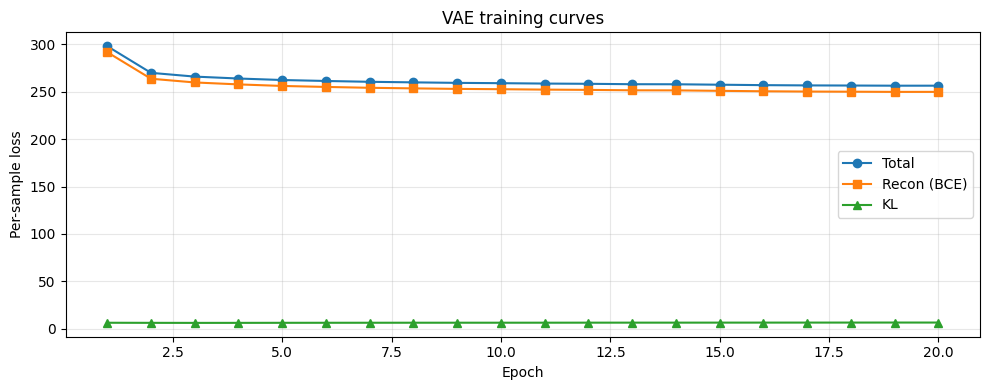

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history["epoch"], history["total"], "o-", label="Total")
plt.plot(history["epoch"], history["recon"], "s-", label="Recon (BCE)")
plt.plot(history["epoch"], history["kl"], "^-", label="KL")
plt.xlabel("Epoch"); plt.ylabel("Per-sample loss"); plt.title("VAE training curves")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 11. Reconstruction

Reconstructions are intentionally a bit **blurry**: the decoder outputs the *probabilistic mean* of a pixel-wise distribution, and an unus term limits how sharp the codes can be. Sharp AE reconstructions come at the cost of an unusable latent space for generation.

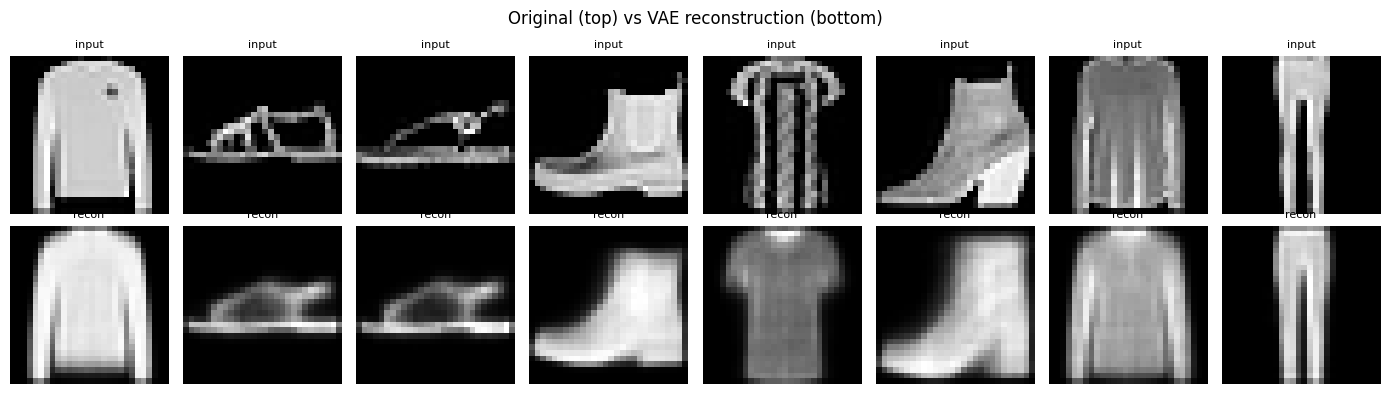

In [19]:
model.eval()
with torch.no_grad():
    x_vis = sample_x[:8].flatten(1).to(device)
    rec, m_vis, lv_vis, z_vis = model(x_vis)
    rec = rec.view(-1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(sample_x[i, 0], cmap="gray"); axes[0, i].set_title("input", fontsize=8); axes[0, i].axis("off")
    axes[1, i].imshow(rec[i], cmap="gray"); axes[1, i].set_title("recon", fontsize=8); axes[1, i].axis("off")
plt.suptitle("Original (top) vs VAE reconstruction (bottom)"); plt.tight_layout(); plt.show()

## 12. Latent Space 2D

Because `latent_dim = 2`, we can scatter **mu** for the whole test set and color by class. Classes form soft clusters, and - thanks to the KL prior term - they sit inside a roughly unit-variance Gaussian cloud rather than flying off to arbitrary coordinates.

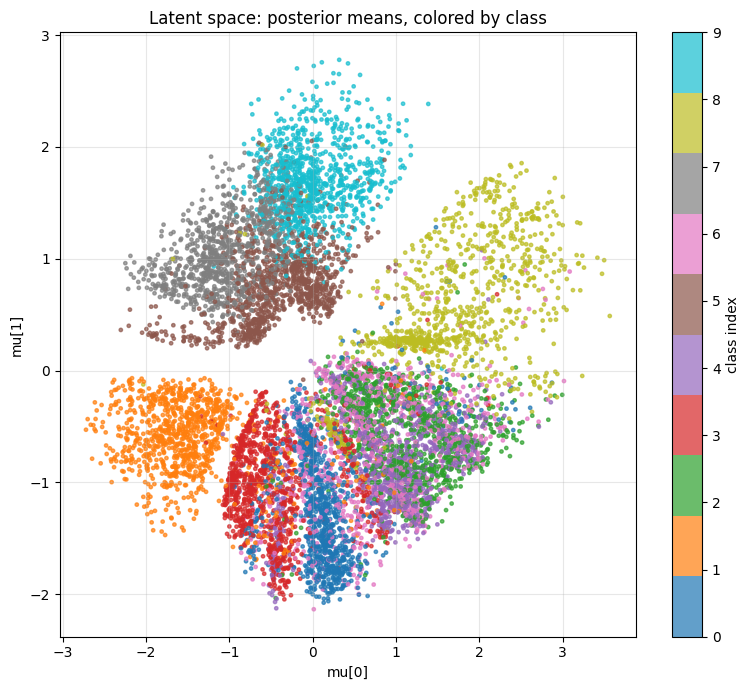

In [20]:
all_mu, all_y = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.flatten(1).to(device)
        _, m, _, _ = model(x)
        all_mu.append(m.cpu()); all_y.append(y)
all_mu = torch.cat(all_mu).numpy(); all_y = torch.cat(all_y).numpy()

plt.figure(figsize=(8, 7))
sc = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_y, s=6, cmap="tab10", alpha=0.7)
plt.colorbar(sc, ticks=range(10)).set_label("class index")
plt.xlabel("mu[0]"); plt.ylabel("mu[1]"); plt.title("Latent space: posterior means, colored by class")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 13. Random Generation

Sample z ~ N(0, I) in the 2-D latent space (`torch.randn(64, latent_dim, device=device)`) and decode. Because the KL term forced the aggregate posterior to match the prior, these random points land in *meaningful* regions - something a deterministic AE cannot do.

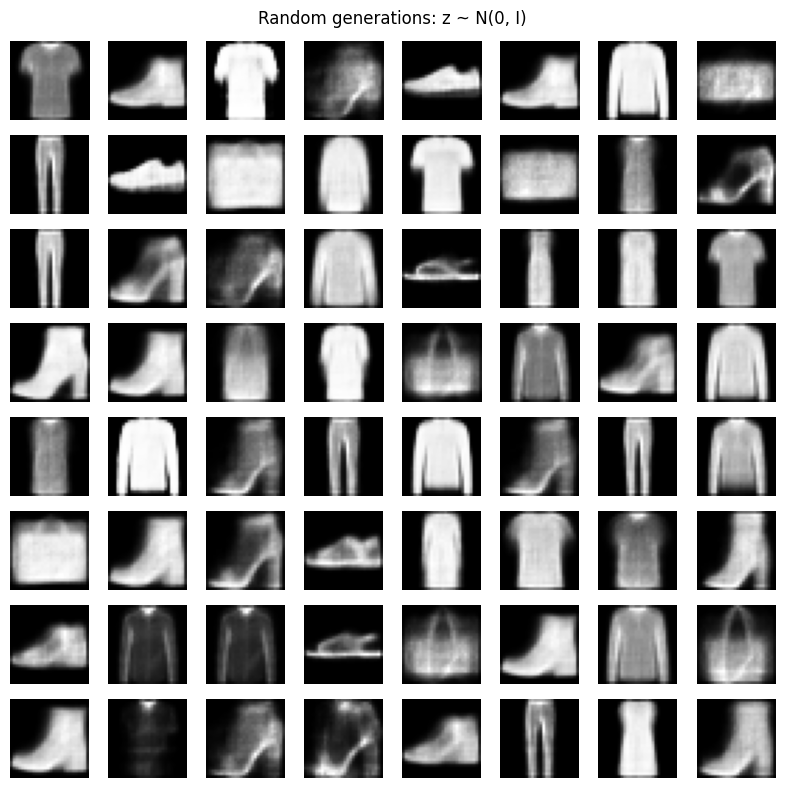

In [21]:
with torch.no_grad():
    z_random = torch.randn(64, latent_dim, device=device)
    gen = model.decode(z_random).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(gen[i], cmap="gray"); ax.axis("off")
plt.suptitle("Random generations: z ~ N(0, I)"); plt.tight_layout(); plt.show()

## 14. Latent Interpolation

Pick two encodings z1, z2 and walk between them in ten steps:

`z(t) = (1 - t) * z1 + t * z2,   t in {0, 0.1, ..., 1}`

Smooth, plausible morphs confirm the latent space is *continuous* - neighboring points decode to neighboring images.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_22828\2866464549.py:6: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  z_interp = torch.tensor([(1 - t) * z1 + t * z2 for t in ts], dtype=torch.float32, device=device)


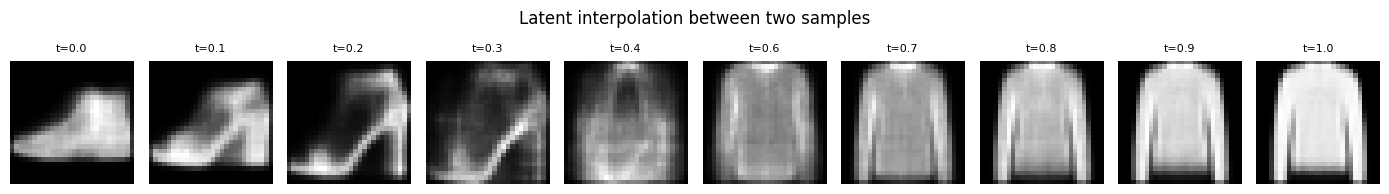

In [22]:
i1, i2 = 0, 1
z1 = all_mu[i1]; z2 = all_mu[i2]
ts = np.linspace(0.0, 1.0, 10)

with torch.no_grad():
    z_interp = torch.tensor([(1 - t) * z1 + t * z2 for t in ts], dtype=torch.float32, device=device)
    imgs = model.decode(z_interp).view(-1, 28, 28).cpu()

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, t in enumerate(ts):
    axes[i].imshow(imgs[i], cmap="gray")
    axes[i].set_title(f"t={t:.1f}", fontsize=8); axes[i].axis("off")
plt.suptitle("Latent interpolation between two samples"); plt.tight_layout(); plt.show()

## 15. PyTorch Distribution API

The same math, expressed declaratively. `Normal` + `Independent` build the diagonal multivariate Gaussian; `rsample()` is the built-in reparameterized sampler; `kl_divergence` computes the exact KL between two distributions - so we can verify our manual KL formula numerically.

In [23]:
from torch.distributions import Normal, Independent, kl_divergence

mu_t = torch.randn(8, latent_dim)
logvar_t = torch.randn(8, latent_dim)
std_t = torch.exp(0.5 * logvar_t)

# q(z|x): diagonal Gaussian with event shape [latent_dim]
q = Independent(Normal(mu_t, std_t), 1)
z_api = q.rsample()                       # reparameterized sample, gradient-friendly

# prior p(z) = N(0, I)
p = Independent(Normal(torch.zeros_like(mu_t), torch.ones_like(std_t)), 1)

kl_api = kl_divergence(q, p)
kl_manual = -0.5 * torch.sum(1 + logvar_t - mu_t.pow(2) - logvar_t.exp(), dim=1)

print("KL API   :", kl_api[:3].tolist())
print("KL manual:", kl_manual[:3].tolist())
print("Max abs difference:", (kl_api - kl_manual).abs().max().item())
print("rsample gradient exists:", z_api.requires_grad)

KL API   : [0.6970368027687073, 1.5826162099838257, 1.4489295482635498]
KL manual: [0.697036862373352, 1.5826163291931152, 1.4489294290542603]
Max abs difference: 4.76837158203125e-07
rsample gradient exists: False


## 16. Test Time - Three Different Operations

At inference we call `model.eval()` and wrap everything in `torch.no_grad()`. Three distinct uses of the trained VAE:

1. **Reconstruction** - encode, sample z, decode: shape [B, 784].
2. **Encoding** - just read (mu, logvar): useful as learned features / compression.
3. **Generation** - ignore the encoder; decode prior samples [64, latent_dim] -> [64, 784].

In [24]:
model.eval()
x_test, y_test = next(iter(test_loader))
x_test = x_test.flatten(1).to(device)

with torch.no_grad():
    # 1) Reconstruction
    rec_out, mu_t2, lv_t2, z_t2 = model(x_test)
    print("Reconstruction shapes: x", tuple(x_test.shape), "-> x_hat", tuple(rec_out.shape))

    # 2) Encoding
    mu_enc, lv_enc = model.encode(x_test)
    print("Encoding shapes: mu", tuple(mu_enc.shape), "| logvar", tuple(lv_enc.shape),
          "| z", tuple(model.reparameterize(mu_enc, lv_enc).shape))

    # 3) Generation from prior
    z_prior = torch.randn(64, latent_dim, device=device)
    gen_out = model.decode(z_prior)
    print("Generation shapes: z", tuple(z_prior.shape), "-> x_gen", tuple(gen_out.shape))

Reconstruction shapes: x (128, 784) -> x_hat (128, 784)
Encoding shapes: mu (128, 2) | logvar (128, 2) | z (128, 2)
Generation shapes: z (64, 2) -> x_gen (64, 784)


## 17. Final Comparison and Summary

| Aspect | Autoencoder (AE) | VAE |
|---|---|---|
| Encoder output | one point z = f(x) | distribution N(mu(x), sigma^2(x)) |
| Latent variable | deterministic code | random via reparameterization z = mu + sigma * eps |
| Loss | reconstruction only | reconstruction **+ KL** to prior |
| Prior / regularization | none (unstructured space) | p(z) = N(0, I) enforced via KL |
| Latent space structure | clusters with meaningless gaps | dense, continuous, prior-organized |
| Interpolation | may cross garbage regions | smooth, plausible morphs |
| Generation from random z | fails | works - decode prior samples |
| Objective | minimize reconstruction error | maximize **ELBO** = recon - KL |

**Mental model.**
- *AE* learns a **compressed lookup table**: encode -> nearest stored code -> decode. Great for compression/denoising; the space between codes is undefined.
- *VAE* learns a **probability model of the data**: the encoder defines q_phi(z|x), the decoder defines p_theta(x|z), and the KL term glues the aggregate posterior to the prior. Training = maximizing the ELBO (lower bound on the data log-likelihood); generation = simply sampling z ~ N(0,I) and decoding.

**What we built:** an MLP VAE (784->256->128->2->128->256->784), trained 20 epochs on FashionMNIST with BCE + exact KL, and verified the manual math against `torch.distributions`. Next steps could include deeper/wider MLPs or more latent dimensions - the code stays identical.